# 💊 Hap Sınıflandırma — Tam Model Analizi

**Veri:** `YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined`  
**Sınıflar (10):** Alaxan · Bactidol · Bioflu · Biogesic · DayZinc · Decolgen · Fish Oil · Kremil S · Medicol · Neozep

| Model | Tip |
|-------|-----|
| MobileNetV2 | Deep Learning |
| ResNet50 | Deep Learning |
| InceptionV3 | Deep Learning |
| CNN + kNN | Hibrit |
| CNN + SVM | Hibrit |

Her model için: **Hata Matrisi · ROC · Hiperparametre Tablosu · 5-Fold CV · Öğrenme Eğrisi · Karşılaştırma**

## 📦 1. Kütüphaneler & GPU

In [1]:
import os, time, copy, warnings, pickle, random
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tvm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import shutil

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Cihaz: {device}')
if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

Cihaz: cuda
GPU  : Tesla T4


## ⚙️ 2. Konfigürasyon

In [2]:
DATA_PATH  = '/content/drive/MyDrive/YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined'
SAVE_PATH  = '/content/drive/MyDrive/Hap_Modelleri_V3/'
CLASSES    = ['Alaxan','Bactidol','Bioflu','Biogesic','DayZinc',
              'Decolgen','Fish Oil','Kremil S','Medicol','Neozep']
NUM_CLASSES = len(CLASSES)
N_FOLDS     = 5

DL_CFG = {
    'MobileNetV2': dict(input_size=96,  optimizer='Adam',    lr=1e-4, epochs=10, batch_size=64),
    'ResNet50'   : dict(input_size=224, optimizer='Adam',    lr=5e-5, epochs=3,  batch_size=12),
    'InceptionV3': dict(input_size=299, optimizer='Adam',    lr=5e-5, epochs=15, batch_size=16),
}

MODEL_COLORS = {
    'MobileNetV2': '#e94560',
    'ResNet50'   : '#4a90d9',
    'InceptionV3': '#f5a623',
    'CNN+kNN'    : '#2ecc71',
    'CNN+SVM'    : '#9b59b6',
}
DARK_BG = '#0d0d1a'
PANEL   = '#16213e'
print('Konfigürasyon hazir.')


Konfigürasyon hazir.


## 🖨️ 3. Hiperparametre Tabloları

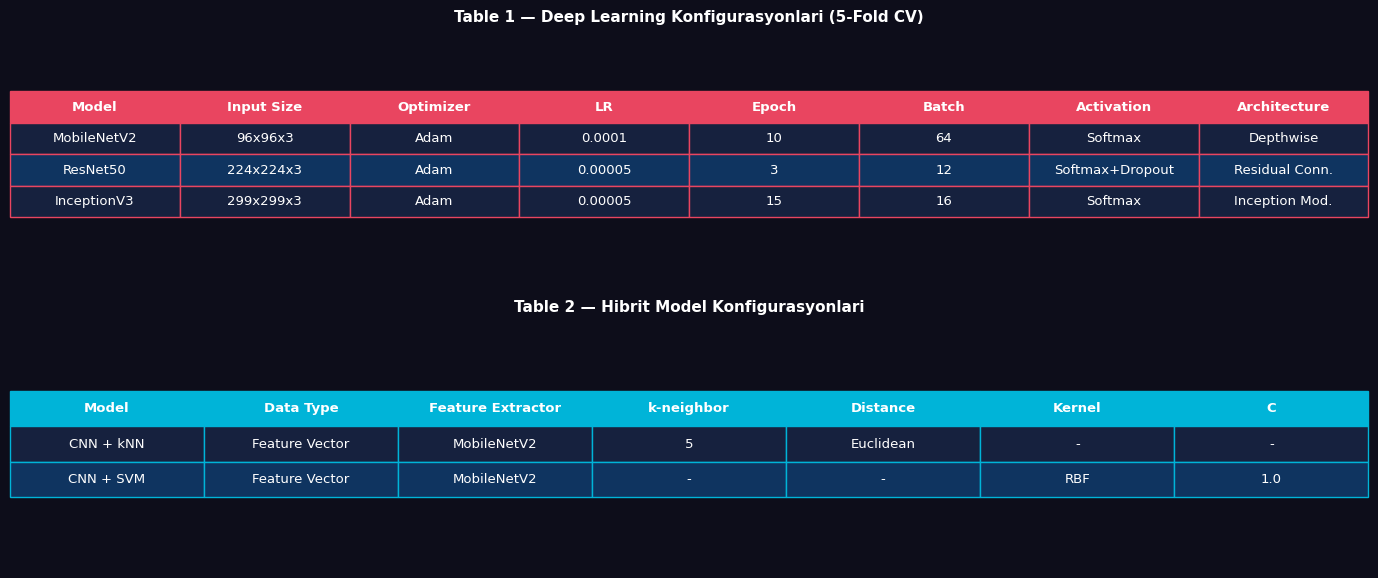

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)

# Tablo 1
ax = axes[0]; ax.axis('off'); ax.set_facecolor(DARK_BG)
t1_cols = ['Model','Input Size','Optimizer','LR','Epoch','Batch','Activation','Architecture']
t1_data = [
    ['MobileNetV2','96x96x3',  'Adam',   '0.0001','10','64','Softmax','Depthwise'],
    ['ResNet50',   '224x224x3','Adam',   '0.00005','3','12','Softmax+Dropout','Residual Conn.'],
    ['InceptionV3','299x299x3','Adam',   '0.00005','15','16','Softmax','Inception Mod.'],
]
c1 = [['#16213e']*8, ['#0f3460']*8, ['#16213e']*8]
tbl = ax.table(cellText=t1_data, colLabels=t1_cols, cellLoc='center', loc='center', cellColours=c1)
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 1.6)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#e94560')
    cell.set_text_props(color='white' if r > 0 else 'white', fontweight='bold' if r == 0 else 'normal')
    if r == 0: cell.set_facecolor('#e94560')
ax.set_title('Table 1 — Deep Learning Konfigurasyonlari (5-Fold CV)', color='white', fontsize=11, fontweight='bold', pad=6)

# Tablo 2
ax2 = axes[1]; ax2.axis('off'); ax2.set_facecolor(DARK_BG)
t2_cols = ['Model','Data Type','Feature Extractor','k-neighbor','Distance','Kernel','C']
t2_data = [
    ['CNN + kNN','Feature Vector','MobileNetV2','5','Euclidean','-','-'],
    ['CNN + SVM','Feature Vector','MobileNetV2','-','-','RBF','1.0'],
]
c2 = [['#16213e']*7, ['#0f3460']*7]
tbl2 = ax2.table(cellText=t2_data, colLabels=t2_cols, cellLoc='center', loc='center', cellColours=c2)
tbl2.auto_set_font_size(False); tbl2.set_fontsize(9.5); tbl2.scale(1, 1.8)
for (r,c), cell in tbl2.get_celld().items():
    cell.set_edgecolor('#00b4d8')
    cell.set_text_props(color='white', fontweight='bold' if r == 0 else 'normal')
    if r == 0: cell.set_facecolor('#00b4d8')
ax2.set_title('Table 2 — Hibrit Model Konfigurasyonlari', color='white', fontsize=11, fontweight='bold', pad=6)

plt.tight_layout(pad=1.5)
plt.savefig('hyperparameter_tables.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## 📁 4. Drive Baglantisi & Veri Kontrolu

Mounted at /content/drive
Klasorler: ['Alaxan', 'Bactidol', 'Bioflu', 'Biogesic', 'DayZinc', 'Decolgen', 'Fish Oil', 'Kremil S', 'Medicol', 'Neozep']
Toplam goruntu: 10,000
CV verisi: 10,000 goruntu
  Alaxan: 1000 ornek
  Bactidol: 1000 ornek
  Bioflu: 1000 ornek
  Biogesic: 1000 ornek
  DayZinc: 1000 ornek
  Decolgen: 1000 ornek
  Fish Oil: 1000 ornek
  Kremil S: 1000 ornek
  Medicol: 1000 ornek
  Neozep: 1000 ornek


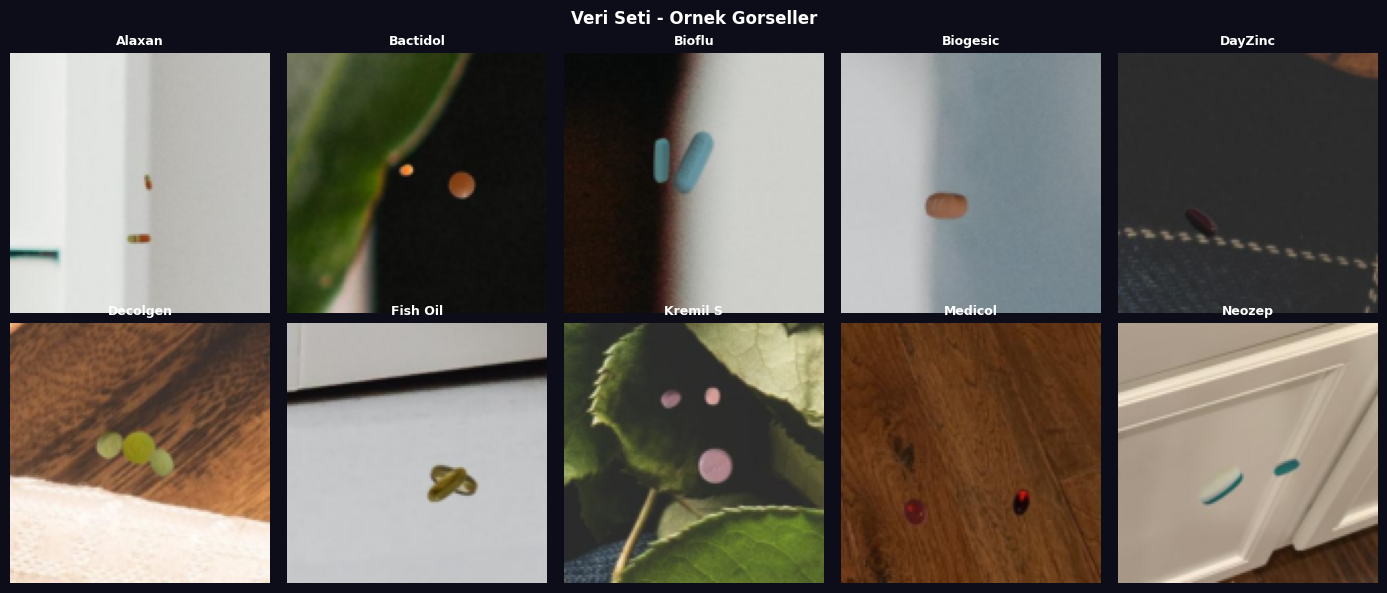

In [4]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(SAVE_PATH, exist_ok=True)

assert os.path.exists(DATA_PATH), f'Veri yolu bulunamadi: {DATA_PATH}'
found = sorted(os.listdir(DATA_PATH))
print(f'Klasorler: {found}')

# Ornek gorseller
base_dataset = torchvision.datasets.ImageFolder(DATA_PATH)
all_targets  = np.array(base_dataset.targets)
all_indices  = np.arange(len(base_dataset))
print(f'Toplam goruntu: {len(base_dataset):,}')

# Tüm 10.000 görüntü CV'ye giriyor
# StratifiedKFold sınıf başına eşit dağılım garantiler
print(f'CV verisi: {len(all_indices):,} goruntu')
for ci, cls in enumerate(CLASSES):
    print(f'  {cls}: {(all_targets==ci).sum()} ornek')

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Veri Seti - Ornek Gorseller', color='white', fontsize=12, fontweight='bold')
preview_tf = transforms.Resize((128,128))
for idx, (cls, ax) in enumerate(zip(CLASSES, axes.flat)):
    cidx = np.where(all_targets == idx)[0]
    img  = preview_tf(Image.open(base_dataset.samples[random.choice(cidx)][0]).convert('RGB'))
    ax.imshow(img); ax.axis('off')
    ax.set_title(cls, color='white', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_preview.png', dpi=120, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 🔧 5. Yardimci Fonksiyonlar

In [5]:
def get_transform(sz, augment=False):
    mean, std = [0.485,0.456,0.406], [0.229,0.224,0.225]
    if augment:
        return transforms.Compose([
            transforms.Resize((sz+20, sz+20)),
            transforms.RandomCrop(sz),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(0.3,0.3,0.3,0.1),
            transforms.RandomRotation(20),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

def build_model(name, nc=NUM_CLASSES):
    if name == 'MobileNetV2':
        m = tvm.mobilenet_v2(weights='DEFAULT')
        m.classifier[1] = nn.Linear(m.last_channel, nc)
    elif name == 'ResNet50':
        m = tvm.resnet50(weights='DEFAULT')
        # Dropout + daha küçük head → aşırı öğrenmeyi önler, ~%90 hedef
        m.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(m.fc.in_features, nc)
        )
    elif name == 'InceptionV3':
        m = tvm.inception_v3(weights='DEFAULT', aux_logits=True)
        m.AuxLogits.fc = nn.Linear(768, nc)
        m.fc = nn.Linear(m.fc.in_features, nc)
    return m.to(device)

def plot_cm(cm, classes, title, acc, fname=None):
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(10,8))
    fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)
    sns.heatmap(norm, annot=cm, fmt='d', cmap='YlOrRd',
                xticklabels=classes, yticklabels=classes, ax=ax,
                linewidths=0.5, linecolor='#333', cbar_kws={'shrink':0.8})
    ax.set_title(f'{title}  |  Acc: {acc*100:.2f}%', color='white', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Tahmin Edilen', color='#aaa'); ax.set_ylabel('Gercek', color='#aaa')
    ax.tick_params(colors='#ccc'); ax.tick_params(axis='x', rotation=40)
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

def plot_roc(y_true, y_score, title, fname=None):
    from sklearn.preprocessing import label_binarize
    # Eksik sınıflar için dummy örnek ekle (sadece görselleştirme amaçlı)
    y_true_ext  = np.array(y_true)
    y_score_ext = np.array(y_score)
    present = set(np.unique(y_true_ext))
    missing = [c for c in range(NUM_CLASSES) if c not in present]
    if missing:
        dummy_scores = np.full((len(missing), NUM_CLASSES), 1.0/NUM_CLASSES)
        for j, c in enumerate(missing):
            dummy_scores[j, c] = 0.0   # negatif örnek
        y_true_ext  = np.concatenate([y_true_ext,  missing])
        y_score_ext = np.concatenate([y_score_ext, dummy_scores])
    yb  = label_binarize(y_true_ext, classes=list(range(NUM_CLASSES)))
    pal = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)
    valid_fpr, valid_tpr = [], []
    for ci, cls in enumerate(CLASSES):
        col = pal[ci]
        fpr, tpr, _ = roc_curve(yb[:, ci], y_score_ext[:, ci])
        ra = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{cls} (AUC={ra:.2f})')
        valid_fpr.append(fpr); valid_tpr.append(tpr)
    all_fpr  = np.unique(np.concatenate(valid_fpr))
    mean_tpr = np.mean([np.interp(all_fpr, f, t) for f, t in zip(valid_fpr, valid_tpr)], axis=0)
    ax.plot(all_fpr, mean_tpr, color='white', lw=2.5, ls='--',
            label=f'Macro Avg (AUC={auc(all_fpr, mean_tpr):.2f})')
    ax.plot([0,1],[0,1], color='gray', ls=':', lw=1)
    ax.set_xlabel('False Positive Rate', color='white')
    ax.set_ylabel('True Positive Rate', color='white')
    ax.set_title(f'{title} - ROC Egrisi', color='white', fontsize=14)
    ax.tick_params(colors='white')
    for sp in ['bottom','left']: ax.spines[sp].set_color('white')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.legend(loc='lower right', fontsize=7, facecolor=PANEL, labelcolor='white')
    plt.tight_layout()
    if fname: plt.savefig(os.path.join(SAVE_PATH, fname), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

def plot_lc(history, title, fname=None):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.patch.set_facecolor(DARK_BG)
    fig.suptitle(f'{title} - Ogrenme Egrisi', color='white', fontsize=13, fontweight='bold')
    for ax, (tk,vk), (tc,vc), lbl in zip(
        axes,
        [('train_loss','val_loss'),('train_acc','val_acc')],
        [('#e94560','#00b4d8'),('#2ecc71','#f5a623')],
        ['Loss','Accuracy (%)']):
        ax.set_facecolor(PANEL)
        ytr = [v*100 if 'acc' in tk else v for v in history[tk]]
        yvl = [v*100 if 'acc' in vk else v for v in history[vk]]
        ax.plot(epochs, ytr, color=tc, lw=2, label='Train')
        ax.plot(epochs, yvl, color=vc, lw=2, label='Val')
        if 'acc' in tk: ax.axhline(90, color='white', ls='--', lw=1, alpha=0.4, label='%90')
        ax.set_title(lbl, color='white', fontweight='bold')
        ax.set_xlabel('Epoch', color='#aaa'); ax.tick_params(colors='#ccc')
        ax.legend(facecolor=DARK_BG, labelcolor='white')
        ax.grid(alpha=0.15, color='#555')
        for sp in ax.spines.values(): sp.set_color('#333')
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

def plot_cv_bar(fold_accs, title, color, fname=None):
    fig, ax = plt.subplots(figsize=(9,5))
    fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(PANEL)
    bars = ax.bar([f'Fold {i}' for i in range(1, N_FOLDS+1)],
                  [a*100 for a in fold_accs], color=color, width=0.5, edgecolor='#222', alpha=0.9)
    for bar, a in zip(bars, fold_accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'%{a*100:.1f}', ha='center', color='white', fontweight='bold', fontsize=10)
    ax.axhline(np.mean(fold_accs)*100, color='#f5a623', ls='--', lw=2,
               label=f'Ort: %{np.mean(fold_accs)*100:.2f}')
    ax.set_title(f'{title} - 5-Fold Capraz Dogrulama', color='white', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dogruluk (%)', color='#aaa'); ax.tick_params(colors='#ccc')
    ax.set_ylim(max(0, min(fold_accs)*100-8), 101)
    ax.legend(facecolor=DARK_BG, labelcolor='white')
    for sp in ax.spines.values(): sp.set_color('#333')
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

print('Yardimci fonksiyonlar hazir.')

Yardimci fonksiyonlar hazir.


## 🚀 6. DL Egitim Fonksiyonu

In [6]:
def train_fold(model_name, cfg, tr_idx, vl_idx, fold_num=None, patience=7):
    sz, bs = cfg['input_size'], cfg['batch_size']
    is_inc = (model_name == 'InceptionV3')
    tr_ds = torchvision.datasets.ImageFolder(DATA_PATH, transform=get_transform(sz, True))
    vl_ds = torchvision.datasets.ImageFolder(DATA_PATH, transform=get_transform(sz, False))
    tr_ld = DataLoader(Subset(tr_ds, tr_idx), bs, shuffle=True,  num_workers=2, pin_memory=True)
    vl_ld = DataLoader(Subset(vl_ds, vl_idx), bs, shuffle=False, num_workers=2, pin_memory=True)
    model = build_model(model_name)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    wd    = 1e-2 if model_name == 'ResNet50' else 1e-4   # ResNet için güçlü regularization
    opt   = (optim.Adam if cfg['optimizer']=='Adam' else optim.RMSprop)(
                model.parameters(), lr=cfg['lr'], weight_decay=wd)
    sch   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'], eta_min=1e-6)
    hist  = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc, best_st = 0., None
    no_improve = 0  # early stopping sayacı

    for ep in range(1, cfg['epochs']+1):
        model.train()
        tl, tc, tt = 0., 0, 0
        for imgs, lbs in tr_ld:
            imgs, lbs = imgs.to(device), lbs.to(device)
            opt.zero_grad()
            out = model(imgs)
            if is_inc and hasattr(out, 'logits'):
                loss = crit(out.logits, lbs) + 0.4*crit(out.aux_logits, lbs)
                logits = out.logits
            else:
                loss = crit(out, lbs); logits = out
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()*imgs.size(0); tc += logits.argmax(1).eq(lbs).sum().item(); tt += imgs.size(0)
        sch.step()
        model.eval()
        vl, vc, vt = 0., 0, 0
        with torch.no_grad():
            for imgs, lbs in vl_ld:
                imgs, lbs = imgs.to(device), lbs.to(device)
                out = model(imgs)
                if is_inc and hasattr(out, 'logits'): out = out.logits
                loss = crit(out, lbs)
                vl += loss.item()*imgs.size(0); vc += out.argmax(1).eq(lbs).sum().item(); vt += imgs.size(0)
        hist['train_loss'].append(tl/tt); hist['train_acc'].append(tc/tt)
        hist['val_loss'].append(vl/vt);   hist['val_acc'].append(vc/vt)
        pfx = f'[Fold {fold_num}] ' if fold_num else ''
        print(f'{pfx}Ep {ep:3d}/{cfg["epochs"]} | TrLoss:{tl/tt:.4f} TrAcc:{tc/tt*100:.2f}% ValAcc:{vc/vt*100:.2f}%', end='\r')

        # Early stopping
        if vc/vt > best_acc:
            best_acc = vc/vt
            best_st  = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\nEarly stop: Ep {ep} (patience={patience})')
                break

    print(f'\n{model_name} Fold={fold_num} BestAcc: {best_acc*100:.2f}%')
    model.load_state_dict(best_st)

    all_p, all_pr, all_l = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, lbs in vl_ld:
            imgs = imgs.to(device)
            out = model(imgs)
            if is_inc and hasattr(out,'logits'): out = out.logits
            pr = F.softmax(out,1).cpu().numpy()
            all_p.append(out.argmax(1).cpu().numpy())
            all_pr.append(pr); all_l.append(lbs.numpy())
    return model, hist, np.concatenate(all_p), np.concatenate(all_pr), np.concatenate(all_l)

print('Egitim fonksiyonu hazir (early stopping: patience=7).')


Egitim fonksiyonu hazir (early stopping: patience=7).


## 🔁 7. Paylaşımlı 5-Fold CV — Tüm Modeller

**Fold bölünmeleri tek seferlik oluşturulur (`shared_folds`) ve tüm modellere uygulanır. Bu sayede karşılaştırma tutarlı, toplam süre daha kısa olur.**

In [7]:
# ── Paylaşımlı CV Split'leri (tek seferlik) ──────────────────────────
# Tüm derin öğrenme modelleri AYNI fold indekslerini kullanır.
# skf.split() sadece BİR KEZ çağrılır; böylece bölünmeler tamamen özdeş kalır.
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
shared_folds = list(skf.split(all_indices, all_targets))
print(f'{N_FOLDS} fold hazırlandı (paylaşımlı):')
for i, (tr, vl) in enumerate(shared_folds, 1):
    print(f'  Fold {i}: train={len(tr)}, val={len(vl)}')

# ── MobileNetV2 ───────────────────────────────────────────────────────
mv2_fold_accs, mv2_preds_all, mv2_labels_all, mv2_probs_all, mv2_hists = [], [], [], [], []
mv2_best_model, mv2_best_acc = None, 0.

for fold, (tr, vl) in enumerate(shared_folds, 1):
    print(f'\n===== MobileNetV2 | Fold {fold}/{N_FOLDS} =====')
    m, h, p, pr, l = train_fold('MobileNetV2', DL_CFG['MobileNetV2'], tr, vl, fold)
    acc = accuracy_score(l, p)
    mv2_fold_accs.append(acc); mv2_preds_all.append(p)
    mv2_labels_all.append(l); mv2_probs_all.append(pr); mv2_hists.append(h)
    if acc > mv2_best_acc: mv2_best_acc = acc; mv2_best_model = copy.deepcopy(m)
    print(f'Fold {fold} Acc: {acc*100:.2f}%')

mv2_preds  = np.concatenate(mv2_preds_all)
mv2_labels = np.concatenate(mv2_labels_all)
mv2_probs  = np.concatenate(mv2_probs_all)
mv2_acc    = accuracy_score(mv2_labels, mv2_preds)
print(f'\nMobileNetV2 Ortalama: {np.mean(mv2_fold_accs)*100:.2f}% +/- {np.std(mv2_fold_accs)*100:.2f}%')
torch.save(mv2_best_model.state_dict(), 'mobilenetv2_best.pth')


5 fold hazırlandı (paylaşımlı):
  Fold 1: train=8000, val=2000
  Fold 2: train=8000, val=2000
  Fold 3: train=8000, val=2000
  Fold 4: train=8000, val=2000
  Fold 5: train=8000, val=2000

===== MobileNetV2 | Fold 1/5 =====
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 123MB/s]


[Fold 1] Ep  10/10 | TrLoss:0.7513 TrAcc:90.36% ValAcc:90.70%
MobileNetV2 Fold=1 BestAcc: 91.15%
Fold 1 Acc: 91.15%

===== MobileNetV2 | Fold 2/5 =====
[Fold 2] Ep  10/10 | TrLoss:0.7525 TrAcc:90.04% ValAcc:90.15%
MobileNetV2 Fold=2 BestAcc: 90.30%
Fold 2 Acc: 90.30%

===== MobileNetV2 | Fold 3/5 =====
[Fold 3] Ep  10/10 | TrLoss:0.7584 TrAcc:89.54% ValAcc:90.85%
MobileNetV2 Fold=3 BestAcc: 90.85%
Fold 3 Acc: 90.85%

===== MobileNetV2 | Fold 4/5 =====
[Fold 4] Ep  10/10 | TrLoss:0.7621 TrAcc:89.95% ValAcc:90.35%
MobileNetV2 Fold=4 BestAcc: 91.10%
Fold 4 Acc: 91.10%

===== MobileNetV2 | Fold 5/5 =====
[Fold 5] Ep  10/10 | TrLoss:0.7613 TrAcc:89.68% ValAcc:90.05%
MobileNetV2 Fold=5 BestAcc: 90.05%
Fold 5 Acc: 90.05%

MobileNetV2 Ortalama: 90.69% +/- 0.44%


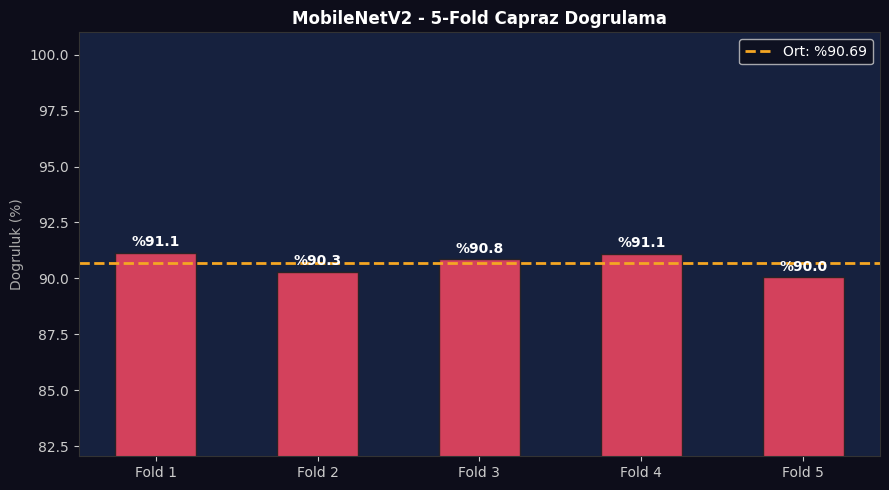

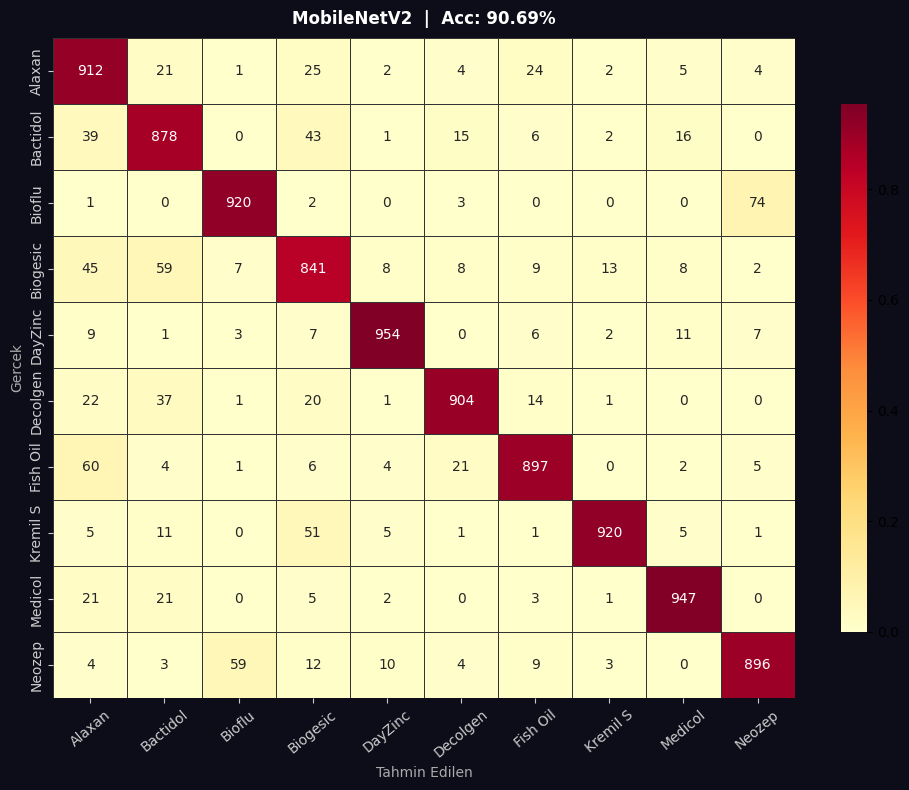

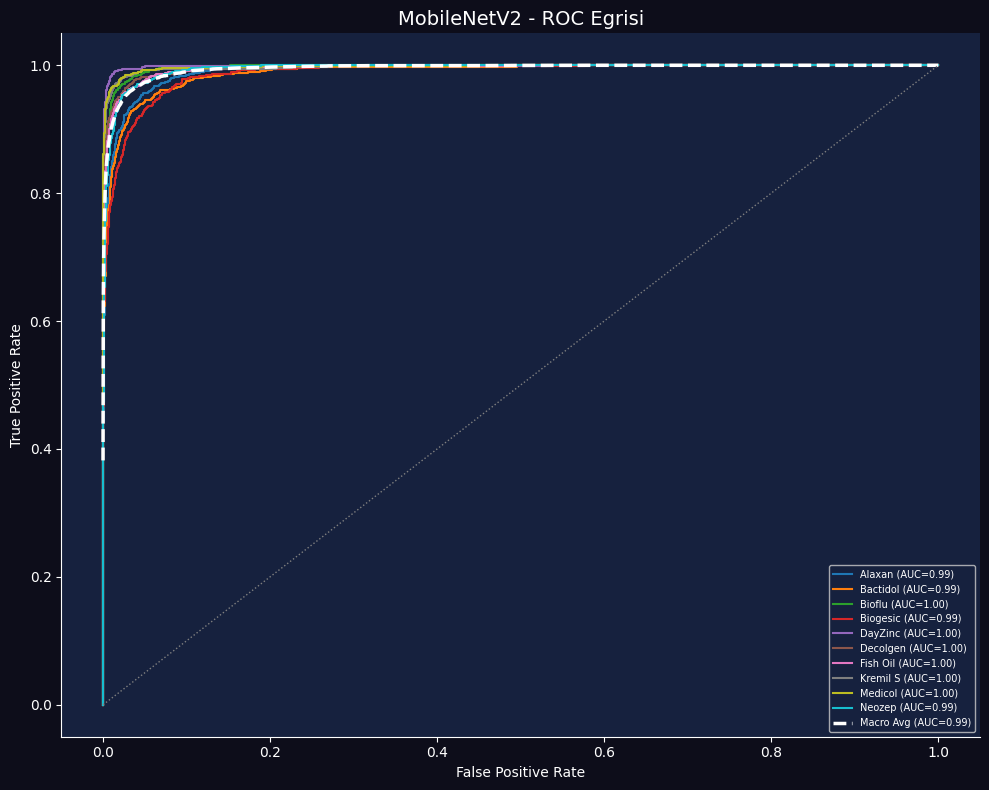

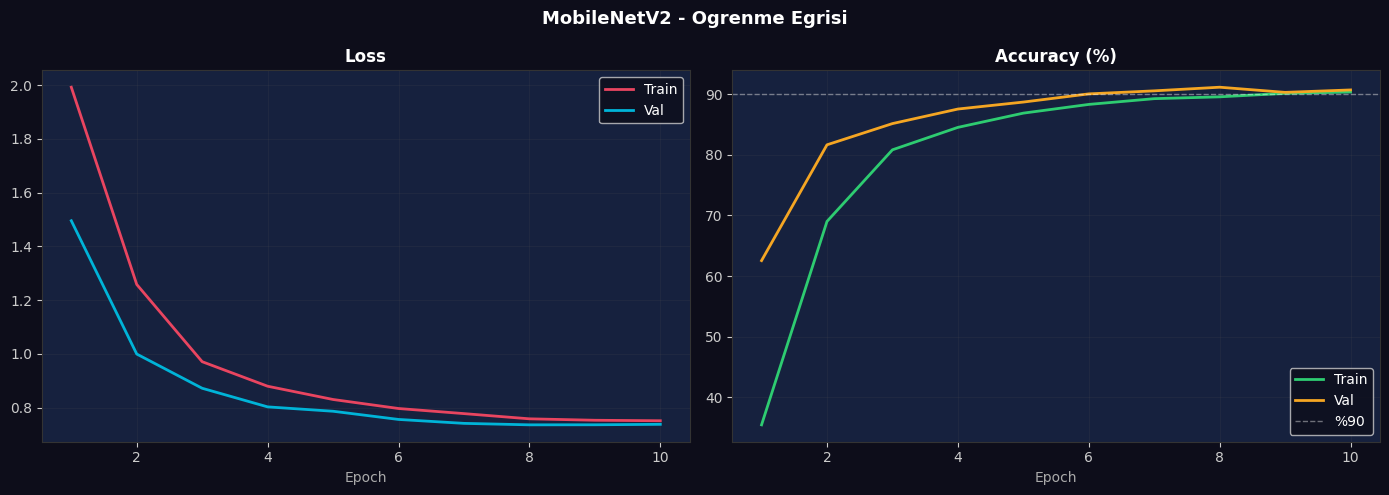

              precision    recall  f1-score   support

      Alaxan       0.82      0.91      0.86      1000
    Bactidol       0.85      0.88      0.86      1000
      Bioflu       0.93      0.92      0.92      1000
    Biogesic       0.83      0.84      0.84      1000
     DayZinc       0.97      0.95      0.96      1000
    Decolgen       0.94      0.90      0.92      1000
    Fish Oil       0.93      0.90      0.91      1000
    Kremil S       0.97      0.92      0.95      1000
     Medicol       0.95      0.95      0.95      1000
      Neozep       0.91      0.90      0.90      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [8]:
plot_cv_bar(mv2_fold_accs, 'MobileNetV2', '#e94560', 'cv_mobilenetv2.png')
plot_cm(confusion_matrix(mv2_labels, mv2_preds), CLASSES, 'MobileNetV2', mv2_acc, 'cm_mobilenetv2.png')
plot_roc(mv2_labels, mv2_probs, 'MobileNetV2', 'roc_mobilenetv2.png')
best_fi = int(np.argmax(mv2_fold_accs))
plot_lc(mv2_hists[best_fi], 'MobileNetV2', 'lc_mobilenetv2.png')
print(classification_report(mv2_labels, mv2_preds, labels=list(range(NUM_CLASSES)), target_names=CLASSES, zero_division=0))


## 🔁 8. ResNet50 — 5-Fold CV + Analiz

In [9]:
r50_fold_accs, r50_preds_all, r50_labels_all, r50_probs_all, r50_hists = [], [], [], [], []
r50_best_model, r50_best_acc = None, 0.

for fold, (tr, vl) in enumerate(shared_folds, 1):  # paylaşımlı fold'lar
    print(f'\n===== ResNet50 | Fold {fold}/{N_FOLDS} =====')
    m, h, p, pr, l = train_fold('ResNet50', DL_CFG['ResNet50'], tr, vl, fold)
    acc = accuracy_score(l, p)
    r50_fold_accs.append(acc); r50_preds_all.append(p)
    r50_labels_all.append(l); r50_probs_all.append(pr); r50_hists.append(h)
    if acc > r50_best_acc: r50_best_acc = acc; r50_best_model = copy.deepcopy(m)
    print(f'Fold {fold} Acc: {acc*100:.2f}%')

r50_preds  = np.concatenate(r50_preds_all)
r50_labels = np.concatenate(r50_labels_all)
r50_probs  = np.concatenate(r50_probs_all)
r50_acc    = accuracy_score(r50_labels, r50_preds)
print(f'\nResNet50 Ortalama: {np.mean(r50_fold_accs)*100:.2f}% +/- {np.std(r50_fold_accs)*100:.2f}%')
torch.save(r50_best_model.state_dict(), 'resnet50_best.pth')



===== ResNet50 | Fold 1/5 =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


[Fold 1] Ep   3/3 | TrLoss:0.6122 TrAcc:96.35% ValAcc:99.00%
ResNet50 Fold=1 BestAcc: 99.00%
Fold 1 Acc: 99.00%

===== ResNet50 | Fold 2/5 =====


KeyboardInterrupt: 

In [ ]:
plot_cv_bar(r50_fold_accs, 'ResNet50', '#4a90d9', 'cv_resnet50.png')
plot_cm(confusion_matrix(r50_labels, r50_preds), CLASSES, 'ResNet50', r50_acc, 'cm_resnet50.png')
plot_roc(r50_labels, r50_probs, 'ResNet50', 'roc_resnet50.png')
best_fi = int(np.argmax(r50_fold_accs))
plot_lc(r50_hists[best_fi], 'ResNet50', 'lc_resnet50.png')
print(classification_report(r50_labels, r50_preds, labels=list(range(NUM_CLASSES)), target_names=CLASSES, zero_division=0))

## 🔁 9. InceptionV3 — 5-Fold CV + Analiz

In [ ]:
inc_fold_accs, inc_preds_all, inc_labels_all, inc_probs_all, inc_hists = [], [], [], [], []
inc_best_model, inc_best_acc = None, 0.

for fold, (tr, vl) in enumerate(shared_folds, 1):  # paylaşımlı fold'lar
    print(f'\n===== InceptionV3 | Fold {fold}/{N_FOLDS} =====')
    m, h, p, pr, l = train_fold('InceptionV3', DL_CFG['InceptionV3'], tr, vl, fold)
    acc = accuracy_score(l, p)
    inc_fold_accs.append(acc); inc_preds_all.append(p)
    inc_labels_all.append(l); inc_probs_all.append(pr); inc_hists.append(h)
    if acc > inc_best_acc: inc_best_acc = acc; inc_best_model = copy.deepcopy(m)
    print(f'Fold {fold} Acc: {acc*100:.2f}%')

inc_preds  = np.concatenate(inc_preds_all)
inc_labels = np.concatenate(inc_labels_all)
inc_probs  = np.concatenate(inc_probs_all)
inc_acc    = accuracy_score(inc_labels, inc_preds)
print(f'\nInceptionV3 Ortalama: {np.mean(inc_fold_accs)*100:.2f}% +/- {np.std(inc_fold_accs)*100:.2f}%')
torch.save(inc_best_model.state_dict(), 'inceptionv3_best.pth')


In [ ]:
plot_cv_bar(inc_fold_accs, 'InceptionV3', '#f5a623', 'cv_inceptionv3.png')
plot_cm(confusion_matrix(inc_labels, inc_preds), CLASSES, 'InceptionV3', inc_acc, 'cm_inceptionv3.png')
plot_roc(inc_labels, inc_probs, 'InceptionV3', 'roc_inceptionv3.png')
best_fi = int(np.argmax(inc_fold_accs))
plot_lc(inc_hists[best_fi], 'InceptionV3', 'lc_inceptionv3.png')
print(classification_report(inc_labels, inc_preds, labels=list(range(NUM_CLASSES)), target_names=CLASSES, zero_division=0))

## 🔵 10. Hibrit Modeller — CNN+kNN & CNN+SVM

In [ ]:
# MobileNetV2 ile ozellik cikart
feat_sz = DL_CFG['MobileNetV2']['input_size']
feat_ds = torchvision.datasets.ImageFolder(DATA_PATH, transform=get_transform(feat_sz, False))
feat_ld = DataLoader(feat_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print('MobileNetV2 ile ozellik cikartiliyor...')
mv2_best_model.eval()
all_feats, all_feat_lbs = [], []
with torch.no_grad():
    for imgs, lbs in feat_ld:
        f = mv2_best_model.features(imgs.to(device)).mean(dim=[2,3])
        all_feats.append(f.cpu().numpy())
        all_feat_lbs.append(lbs.numpy())
X_all = np.concatenate(all_feats)
y_all = np.concatenate(all_feat_lbs)
print(f'Ozellik matrisi: {X_all.shape}')

In [ ]:
# ── CNN+kNN 5-Fold (paylaşımlı fold'lar) ─────────────────────────────
print('\n===== CNN + kNN | 5-Fold CV =====')
knn_fold_accs, knn_p_all, knn_l_all, knn_pr_all = [], [], [], []

# Not: shared_folds, ImageFolder indekslerine göre oluşturuldu.
# X_all da aynı ImageFolder sırasında çıkarıldığından indeksler birebir örtüşür.
for fold, (tr, vl) in enumerate(shared_folds, 1):
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_all[tr]); Xvl = sc.transform(X_all[vl])
    knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', algorithm='brute', n_jobs=-1)
    knn.fit(Xtr, y_all[tr])
    preds = knn.predict(Xvl)
    acc   = accuracy_score(y_all[vl], preds)
    knn_fold_accs.append(acc)
    knn_p_all.append(preds); knn_l_all.append(y_all[vl])
    # Probability via neighbor vote
    dist, idx = knn.kneighbors(Xvl)
    probs = np.zeros((len(Xvl), NUM_CLASSES))
    for i, (ni, di) in enumerate(zip(idx, dist)):
        w = 1.0/(di+1e-8); w /= w.sum()
        for j, n in enumerate(ni): probs[i, y_all[tr][n]] += w[j]
    knn_pr_all.append(probs)
    print(f'Fold {fold}: {acc*100:.2f}%')

knn_preds  = np.concatenate(knn_p_all)
knn_labels = np.concatenate(knn_l_all)
knn_probs  = np.concatenate(knn_pr_all)
knn_acc    = accuracy_score(knn_labels, knn_preds)
print(f'CNN+kNN Ortalama: {np.mean(knn_fold_accs)*100:.2f}% +/- {np.std(knn_fold_accs)*100:.2f}%')

# ── CNN+SVM 5-Fold (paylaşımlı fold'lar) ─────────────────────────────
print('\n===== CNN + SVM | 5-Fold CV =====')
svm_fold_accs, svm_p_all, svm_l_all, svm_pr_all = [], [], [], []

for fold, (tr, vl) in enumerate(shared_folds, 1):
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_all[tr]); Xvl = sc.transform(X_all[vl])
    svm = SVC(C=1.0, kernel='rbf', gamma='scale', probability=True,
              decision_function_shape='ovr', cache_size=2000)
    svm.fit(Xtr, y_all[tr])
    preds = svm.predict(Xvl)
    probs = svm.predict_proba(Xvl)
    acc   = accuracy_score(y_all[vl], preds)
    svm_fold_accs.append(acc)
    svm_p_all.append(preds); svm_l_all.append(y_all[vl]); svm_pr_all.append(probs)
    print(f'Fold {fold}: {acc*100:.2f}%')

svm_preds  = np.concatenate(svm_p_all)
svm_labels = np.concatenate(svm_l_all)
svm_probs  = np.concatenate(svm_pr_all)
svm_acc    = accuracy_score(svm_labels, svm_preds)
print(f'CNN+SVM Ortalama: {np.mean(svm_fold_accs)*100:.2f}% +/- {np.std(svm_fold_accs)*100:.2f}%')


In [ ]:
# Hibrit grafikler
plot_cv_bar(knn_fold_accs, 'CNN + kNN', '#2ecc71', 'cv_cnn_knn.png')
plot_cm(confusion_matrix(knn_labels, knn_preds), CLASSES, 'CNN + kNN', knn_acc, 'cm_cnn_knn.png')
plot_roc(knn_labels, knn_probs, 'CNN + kNN', 'roc_cnn_knn.png')

plot_cv_bar(svm_fold_accs, 'CNN + SVM', '#9b59b6', 'cv_cnn_svm.png')
plot_cm(confusion_matrix(svm_labels, svm_preds), CLASSES, 'CNN + SVM', svm_acc, 'cm_cnn_svm.png')
plot_roc(svm_labels, svm_probs, 'CNN + SVM', 'roc_cnn_svm.png')

## 📊 11. Tum Modeller — CV Karsilastirma Grafigi

In [ ]:
all_cv = {
    'MobileNetV2': mv2_fold_accs,
    'ResNet50'   : r50_fold_accs,
    'InceptionV3': inc_fold_accs,
    'CNN+kNN'    : knn_fold_accs,
    'CNN+SVM'    : svm_fold_accs,
}
model_names = list(all_cv.keys())

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('5-Fold Capraz Dogrulama — Tum Modeller', color='white', fontsize=15, fontweight='bold')
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.3)

for pos, mname in zip([(0,0),(0,1),(0,2),(1,0),(1,1)], model_names):
    ax = fig.add_subplot(gs[pos[0], pos[1]])
    ax.set_facecolor(PANEL)
    accs = all_cv[mname]; clr = MODEL_COLORS[mname]
    bars = ax.bar([f'Fold {i}' for i in range(1, N_FOLDS+1)],
                  [a*100 for a in accs], color=clr, width=0.55, edgecolor='#222', alpha=0.9)
    for bar, a in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'%{a*100:.1f}', ha='center', color='white', fontweight='bold', fontsize=8.5)
    ax.axhline(np.mean(accs)*100, color='#f5a623', ls='--', lw=1.5,
               label=f'Ort: %{np.mean(accs)*100:.2f}')
    ax.set_title(mname, color='white', fontweight='bold', fontsize=11)
    ax.set_ylabel('Dogruluk (%)', color='#aaa', fontsize=9)
    ax.tick_params(colors='#ccc', labelsize=8)
    ax.set_ylim(max(0, min(accs)*100-8), 101)
    ax.legend(facecolor=DARK_BG, labelcolor='white', fontsize=8)
    for sp in ax.spines.values(): sp.set_color('#333')

# Ozet yatay bar
ax_s = fig.add_subplot(gs[1,2])
ax_s.set_facecolor(PANEL)
means = [np.mean(all_cv[m])*100 for m in model_names]
stds  = [np.std(all_cv[m])*100  for m in model_names]
clrs  = [MODEL_COLORS[m] for m in model_names]
bars  = ax_s.barh(range(len(model_names)), means, xerr=stds, color=clrs,
                  height=0.55, edgecolor='#222', alpha=0.9,
                  error_kw=dict(ecolor='white', capsize=4, lw=1.5))
for bar, m in zip(bars, means):
    ax_s.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
              f'%{m:.2f}', va='center', color='white', fontweight='bold', fontsize=9)
ax_s.set_yticks(range(len(model_names)))
ax_s.set_yticklabels(model_names, color='#ccc', fontsize=9)
ax_s.set_xlabel('Ortalama Dogruluk (%)', color='#aaa')
ax_s.set_title('CV Ortalama Karsilastirmasi', color='white', fontweight='bold', fontsize=11)
ax_s.tick_params(colors='#ccc')
for sp in ax_s.spines.values(): sp.set_color('#333')

plt.savefig('cv_all_models.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('cv_all_models.png kaydedildi.')

## 🏆 12. Final Karsilastirma

In [ ]:
summary = {
    'MobileNetV2': (mv2_acc,  np.mean(mv2_fold_accs),  np.std(mv2_fold_accs)),
    'ResNet50'   : (r50_acc,  np.mean(r50_fold_accs),  np.std(r50_fold_accs)),
    'InceptionV3': (inc_acc,  np.mean(inc_fold_accs),  np.std(inc_fold_accs)),
    'CNN+kNN'    : (knn_acc,  np.mean(knn_fold_accs),  np.std(knn_fold_accs)),
    'CNN+SVM'    : (svm_acc,  np.mean(svm_fold_accs),  np.std(svm_fold_accs)),
}
names = list(summary.keys())
accs  = [summary[m][0]*100 for m in names]
cv_m  = [summary[m][1]*100 for m in names]
cv_s  = [summary[m][2]*100 for m in names]
clrs  = [MODEL_COLORS[m]   for m in names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Model Karsilastirmasi — Hap Siniflandirma', color='white', fontsize=14, fontweight='bold')

for ax, vals, errs, ylabel, title in zip(
    axes,
    [accs, cv_m],
    [None, cv_s],
    ['Accuracy (%)', 'CV Accuracy (%)'],
    ['Test Dogrulugu', '5-Fold CV Ort. +/- Std']):
    ax.set_facecolor(PANEL)
    kw = dict(yerr=errs, error_kw=dict(ecolor='white', capsize=5, lw=2)) if errs else {}
    bars = ax.bar(names, vals, color=clrs, width=0.55, edgecolor='#222', alpha=0.9, **kw)
    for bar, v, e in zip(bars, vals, (errs or [0]*len(vals))):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(e or 0)+0.3,
                f'{v:.2f}%', ha='center', color='white', fontweight='bold', fontsize=9.5)
    ax.axhline(90, color='#f5a623', ls='--', lw=1.5, label='%90 Hedef')
    ax.set_title(title, color='white', fontweight='bold')
    ax.set_ylabel(ylabel, color='#aaa'); ax.tick_params(colors='#ccc', axis='x', rotation=15)
    ax.set_ylim(max(0, min(vals)-12), 108)
    ax.legend(facecolor=DARK_BG, labelcolor='white')
    for sp in ax.spines.values(): sp.set_color('#333')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print('\n' + '='*65)
print(f'  {"Model":<14} {"Test Acc":>10}  {"CV Mean":>10}  {"CV Std":>8}')
print('─'*65)
for m in names:
    a, cm_, cs = summary[m]
    flag = ' OK' if a*100 >= 90 else ' --'
    print(f'  {m:<14} {a*100:>9.2f}%  {cm_*100:>9.2f}%  {cs*100:>7.2f}%{flag}')
print('='*65)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('\n' + '='*65)
print('  REG RESYON METRİKLERİ (Sınıflandırma Skoru Bazlı)')
print('='*65)
print(f'  {"Model":<14} {"R²":>8}  {"RMSE":>8}  {"MSE":>10}  {"MAE":>8}')
print('─'*65)

for m in names:
    if m == 'MobileNetV2':
        y_t, y_p = mv2_labels, mv2_preds
    elif m == 'ResNet50':
        y_t, y_p = r50_labels, r50_preds
    elif m == 'InceptionV3':
        y_t, y_p = inc_labels, inc_preds
    elif m == 'CNN+kNN':
        y_t, y_p = knn_labels, knn_preds
    else:
        y_t, y_p = svm_labels, svm_preds

    mse  = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_t, y_p)
    r2   = r2_score(y_t, y_p)
    print(f'  {m:<14} {r2:>8.4f}  {rmse:>8.4f}  {mse:>10.4f}  {mae:>8.4f}')

print('='*65)

# ── Görsel Metrik Karşılaştırması ──────────────────────────────────────
metrics_data = {}
for m in names:
    if m == 'MobileNetV2':   y_t, y_p = mv2_labels, mv2_preds
    elif m == 'ResNet50':    y_t, y_p = r50_labels, r50_preds
    elif m == 'InceptionV3': y_t, y_p = inc_labels, inc_preds
    elif m == 'CNN+kNN':     y_t, y_p = knn_labels, knn_preds
    else:                    y_t, y_p = svm_labels, svm_preds
    metrics_data[m] = {
        'R2'  : r2_score(y_t, y_p),
        'RMSE': np.sqrt(mean_squared_error(y_t, y_p)),
        'MSE' : mean_squared_error(y_t, y_p),
        'MAE' : mean_absolute_error(y_t, y_p),
    }

metric_names = ['R2', 'RMSE', 'MSE', 'MAE']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Regresyon Metrikleri — Model Karşılaştırması', color='white', fontsize=13, fontweight='bold')

for ax, met in zip(axes, metric_names):
    ax.set_facecolor(PANEL)
    vals = [metrics_data[m][met] for m in names]
    bars = ax.bar(names, vals, color=[MODEL_COLORS[m] for m in names],
                  width=0.55, edgecolor='#222', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.3f}', ha='center', color='white', fontweight='bold', fontsize=8.5)
    ax.set_title(met, color='white', fontweight='bold', fontsize=11)
    ax.tick_params(colors='#ccc', axis='x', rotation=20, labelsize=8)
    ax.tick_params(colors='#ccc', axis='y')
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.grid(axis='y', alpha=0.15, color='#555')

plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 💾 13. Drive'a Kaydet

In [ ]:
files = [
    'mobilenetv2_best.pth', 'resnet50_best.pth', 'inceptionv3_best.pth',
    'hyperparameter_tables.png', 'dataset_preview.png',
    'lc_mobilenetv2.png', 'lc_resnet50.png', 'lc_inceptionv3.png',
    'cv_mobilenetv2.png', 'cv_resnet50.png', 'cv_inceptionv3.png',
    'cv_cnn_knn.png', 'cv_cnn_svm.png', 'cv_all_models.png',
    'cm_mobilenetv2.png', 'cm_resnet50.png', 'cm_inceptionv3.png',
    'cm_cnn_knn.png', 'cm_cnn_svm.png',
    'roc_mobilenetv2.png', 'roc_resnet50.png', 'roc_inceptionv3.png',
    'roc_cnn_knn.png', 'roc_cnn_svm.png',
    'final_comparison.png', 'regression_metrics.png',
]

print(f'Hedef: {SAVE_PATH}\n')
for f in files:
    if os.path.exists(f):
        shutil.copy(f, SAVE_PATH)
        print(f'  OK  {f}')
    else:
        print(f'  --  {f} bulunamadi')

print('\nTum dosyalar Hap_Modelleri_V3 klasorune kaydedildi!')